In [3]:
import os

# Define the subdirectories to be created
subdirectories = ['data_pipeline', 'analytics', 'support_assistant']

# Create each subdirectory within the project_dir
for subdir in subdirectories:
    path = os.path.join(project_dir, subdir)
    os.makedirs(path, exist_ok=True)
    print(f"Created directory: {path}")

# Verify the creation of the new directories
print(f"\nUpdated contents of '{project_dir}':")
!ls -F {project_dir}

Created directory: capstone-project/data_pipeline
Created directory: capstone-project/analytics
Created directory: capstone-project/support_assistant

Updated contents of 'capstone-project':
analytics/  data_pipeline/  README.md  support_assistant/


In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Define the base URL
base_url = "http://books.toscrape.com/"

# List to store all scraped book data
all_books_data = []

print("Libraries imported and base URL/data list initialized.")

Libraries imported and base URL/data list initialized.


In [5]:
import re # Import regex for cleaning strings

# Define the categories to scrape and their corresponding URLs
categories = {
    "Travel": "catalogue/category/books/travel_2/index.html",
    "Mystery": "catalogue/category/books/mystery_3/index.html",
    "Historical Fiction": "catalogue/category/books/historical-fiction_4/index.html"
}

# Loop through each category
for category_name, category_path in categories.items():
    url = base_url + category_path
    print(f"Scraping category: {category_name} from {url}")

    try:
        response = requests.get(url)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Find all book articles on the page
        books = soup.find_all('article', class_='product_pod')

        for book in books:
            title = book.h3.a['title']

            # Price extraction and cleaning
            price_str = book.find('p', class_='price_color').text
            price = float(re.search(r'\d+\.\d+', price_str).group())

            # Star rating extraction and conversion
            star_rating_text = book.find('p', class_=re.compile('star-rating')).get('class')[1]
            star_rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
            star_rating = star_rating_map.get(star_rating_text, 0)

            # Availability extraction and cleaning
            availability_str = book.find('p', class_='instock availability').text.strip()
            availability = availability_str.replace('In stock', '').strip()

            all_books_data.append({
                'title': title,
                'price': price,
                'star_rating': star_rating,
                'availability': availability,
                'category': category_name
            })

    except requests.exceptions.RequestException as e:
        print(f"Error fetching {url}: {e}")
    except AttributeError as e:
        print(f"Error parsing book data on {url}: {e}. Skipping some books.")
    except Exception as e:
        print(f"An unexpected error occurred for {url}: {e}")

print(f"\nScraped {len(all_books_data)} books in total.")

# Convert the list of dictionaries to a pandas DataFrame
df_books = pd.DataFrame(all_books_data)

# Display the first few rows of the DataFrame
print("\nFirst 5 rows of the scraped data:")
print(df_books.head())

# Display the shape of the DataFrame
print(f"\nShape of the DataFrame: {df_books.shape}")

Scraping category: Travel from http://books.toscrape.com/catalogue/category/books/travel_2/index.html
Scraping category: Mystery from http://books.toscrape.com/catalogue/category/books/mystery_3/index.html
Scraping category: Historical Fiction from http://books.toscrape.com/catalogue/category/books/historical-fiction_4/index.html

Scraped 51 books in total.

First 5 rows of the scraped data:
                                               title  price  star_rating  \
0                            It's Only the Himalayas  45.17            2   
1  Full Moon over Noahâs Ark: An Odyssey to Mou...  49.43            4   
2  See America: A Celebration of Our National Par...  48.87            3   
3  Vagabonding: An Uncommon Guide to the Art of L...  36.94            2   
4                               Under the Tuscan Sun  37.33            3   

  availability category  
0                Travel  
1                Travel  
2                Travel  
3                Travel  
4                T

In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re # Import regex for cleaning strings

# Initialize an empty list to store the scraped book data, clearing any previously stored data
all_books_data = []

# Define the base URL for the 'All products' paginated catalogue
base_url_all_products = "http://books.toscrape.com/catalogue/page-"

# Loop through the first 5 paginated pages
for page_num in range(1, 6):
    url = f"{base_url_all_products}{page_num}.html"
    print(f"Scraping page: {page_num} from {url}")

    try:
        response = requests.get(url)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Find all book articles on the page
        books = soup.find_all('article', class_='product_pod')

        for book in books:
            title = book.h3.a['title']

            # Price extraction and cleaning
            price_str = book.find('p', class_='price_color').text
            price = float(re.search(r'\d+\.\d+', price_str).group())

            # Star rating extraction and conversion
            star_rating_text = book.find('p', class_=re.compile('star-rating')).get('class')[1]
            star_rating_map = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
            star_rating = star_rating_map.get(star_rating_text, 0)

            # Availability extraction and cleaning
            availability_str = book.find('p', class_='instock availability').text.strip()
            # Remove 'In stock' and leading/trailing whitespace
            availability = availability_str.replace('In stock', '').strip()

            # Assign 'All Products' as the category for books from these pages
            category = 'All Products'

            all_books_data.append({
                'title': title,
                'price': price,
                'star_rating': star_rating,
                'availability': availability,
                'category': category
            })

    except requests.exceptions.RequestException as e:
        print(f"Error fetching {url}: {e}")
    except AttributeError as e:
        print(f"Error parsing book data on {url}: {e}. Skipping some books.")
    except Exception as e:
        print(f"An unexpected error occurred for {url}: {e}")

print(f"\nScraped {len(all_books_data)} books in total from 'All Products' pages.")

# Convert the list of dictionaries to a pandas DataFrame
df_books = pd.DataFrame(all_books_data)

# Display the first few rows of the DataFrame
print("\nFirst 5 rows of the scraped data:")
print(df_books.head())

# Display the shape of the DataFrame
print(f"\nShape of the DataFrame: {df_books.shape}")


Scraping page: 1 from http://books.toscrape.com/catalogue/page-1.html
Scraping page: 2 from http://books.toscrape.com/catalogue/page-2.html
Scraping page: 3 from http://books.toscrape.com/catalogue/page-3.html
Scraping page: 4 from http://books.toscrape.com/catalogue/page-4.html
Scraping page: 5 from http://books.toscrape.com/catalogue/page-5.html

Scraped 100 books in total from 'All Products' pages.

First 5 rows of the scraped data:
                                   title  price  star_rating availability  \
0                   A Light in the Attic  51.77            3                
1                     Tipping the Velvet  53.74            1                
2                             Soumission  50.10            1                
3                          Sharp Objects  47.82            4                
4  Sapiens: A Brief History of Humankind  54.23            5                

       category  
0  All Products  
1  All Products  
2  All Products  
3  All Products  
4  All 

In [7]:
import numpy as np

# 1. Convert 'price' to 'price_gbp' (float)
# The 'price' column was already extracted as float in the scraping step.
# Renaming the column to 'price_gbp'.
df_books['price_gbp'] = df_books['price'].astype(float)

# 2. Convert 'star_rating' to 'rating' (integer 1-5)
# The 'star_rating' column was already converted to an integer in the scraping step.
# Renaming the column to 'rating'.
df_books['rating'] = df_books['star_rating'].astype(int)

# 3. Parse 'availability' to 'in_stock' (boolean)
# Based on the scraping logic, an empty string '' in 'availability' means 'In stock'.
# So, if 'availability' is an empty string, set 'in_stock' to True, otherwise False.
df_books['in_stock'] = df_books['availability'].apply(lambda x: True if x == '' else False)

# 4. Convert price_gbp to price_inr using 1 GBP = 105.50 INR
GBP_TO_INR_RATE = 105.50
df_books['price_inr'] = df_books['price_gbp'] * GBP_TO_INR_RATE

# Drop the original 'price', 'star_rating', and 'availability' columns as they have been transformed
df_books.drop(columns=['price', 'star_rating', 'availability'], inplace=True)

print("Data cleaning and conversion complete.")

# Display the first few rows of the updated DataFrame
print("\nFirst 5 rows of the cleaned data:")
print(df_books.head())

# Display the DataFrame information to verify new columns and data types
print("\nDataFrame Info:")
df_books.info()

Data cleaning and conversion complete.

First 5 rows of the cleaned data:
                                   title      category  price_gbp  rating  \
0                   A Light in the Attic  All Products      51.77       3   
1                     Tipping the Velvet  All Products      53.74       1   
2                             Soumission  All Products      50.10       1   
3                          Sharp Objects  All Products      47.82       4   
4  Sapiens: A Brief History of Humankind  All Products      54.23       5   

   in_stock  price_inr  
0      True   5461.735  
1      True   5669.570  
2      True   5285.550  
3      True   5045.010  
4      True   5721.265  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      100 non-null    object 
 1   category   100 non-null    object 
 2   price_gbp  100 non-null    f

In [8]:
import sqlite3
import os

# Define the path for the new SQLite database file
db_dir = os.path.join(project_dir, 'data_pipeline')
db_path = os.path.join(db_dir, 'books.db')

# Ensure the directory exists
os.makedirs(db_dir, exist_ok=True)

# Establish a connection to the SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

print(f"SQLite database connection established at: {db_path}")

SQLite database connection established at: capstone-project/data_pipeline/books.db


In [9]:
import sqlite3
import pandas as pd
import os

# Re-establish connection if it was closed in previous blocks or for robustness
# The db_path and db_dir should still be available from the previous cell.
# If not, they would need to be re-defined here.
# For this execution, assuming db_path and db_dir are available.

conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# 1. Create 'categories' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS categories (
    category_id INTEGER PRIMARY KEY AUTOINCREMENT,
    category_name TEXT UNIQUE NOT NULL
);
''')
print("Table 'categories' created or already exists.")

# 2. Create 'books' table
cursor.execute('''
CREATE TABLE IF NOT EXISTS books (
    book_id INTEGER PRIMARY KEY AUTOINCREMENT,
    title TEXT NOT NULL,
    price_gbp REAL,
    rating INTEGER,
    in_stock BOOLEAN,
    price_inr REAL,
    category_id INTEGER,
    FOREIGN KEY (category_id) REFERENCES categories(category_id)
);
''')
print("Table 'books' created or already exists.")

# 3. Extract unique category names from df_books and insert into 'categories'
unique_categories = df_books['category'].unique()
for category in unique_categories:
    cursor.execute('INSERT OR IGNORE INTO categories (category_name) VALUES (?)', (category,))
conn.commit()
print(f"Inserted {len(unique_categories)} unique categories into 'categories' table.")

# 4. Retrieve category_id for each category name and merge into df_books
# First, fetch all categories with their IDs from the database
category_ids_df = pd.read_sql_query("SELECT category_id, category_name FROM categories", conn)

# Merge df_books with category_ids_df to get the category_id
df_books_with_ids = pd.merge(df_books, category_ids_df, left_on='category', right_on='category_name', how='left')

# 5. Insert the df_books_with_ids DataFrame into the 'books' table
# Select only the columns relevant for the 'books' table, including category_id
books_to_insert = df_books_with_ids[['title', 'price_gbp', 'rating', 'in_stock', 'price_inr', 'category_id']]

books_to_insert.to_sql('books', conn, if_exists='append', index=False)
print(f"Inserted {len(books_to_insert)} books into 'books' table.")

# 6. Commit the changes and close the connection
conn.commit()
conn.close()
print("Database changes committed and connection closed.")

# 7. Verify that the books.db file exists
print(f"\nVerifying database file: {db_path}")
if os.path.exists(db_path):
    print("Database file 'books.db' created successfully.")
else:
    print("Error: Database file 'books.db' not found.")

# Optional: Display tables for verification (re-open connection for this)
# conn_check = sqlite3.connect(db_path)
# print("\nCategories table content:")
# print(pd.read_sql_query("SELECT * FROM categories", conn_check))
# print("\nBooks table content (first 5 rows):")
# print(pd.read_sql_query("SELECT * FROM books LIMIT 5", conn_check))
# conn_check.close()

Table 'categories' created or already exists.
Table 'books' created or already exists.
Inserted 1 unique categories into 'categories' table.
Inserted 100 books into 'books' table.
Database changes committed and connection closed.

Verifying database file: capstone-project/data_pipeline/books.db
Database file 'books.db' created successfully.


In [10]:
import sqlite3
import pandas as pd
import os

# Re-establish connection to the database
# Assuming project_dir and db_dir are still available from previous cells.
# If not, uncomment and define them:
# project_dir = "capstone-project"
# db_dir = os.path.join(project_dir, 'data_pipeline')
# db_path = os.path.join(db_dir, 'books.db')

conn = sqlite3.connect(db_path)
cursor = conn.cursor()
print(f"Re-established SQLite database connection at: {db_path}")

# Dictionary to store query strings and their results
query_results = {}

# --- 1. SELECT with WHERE clause: Books with rating 4 or higher ---
sql_query_where = "SELECT title, rating, price_gbp FROM books WHERE rating >= 4 ORDER BY rating DESC, price_gbp DESC LIMIT 10;"
query_results['rating_gte_4'] = pd.read_sql(sql_query_where, conn)
print("\n--- Query 1: Books with rating 4 or higher ---")
print(f"SQL Query:\n{sql_query_where}")
print("Result (first 10 rows):")
print(query_results['rating_gte_4'])

# --- 2. ORDER BY: Books ordered by price_gbp in descending order ---
sql_query_order_by = "SELECT title, price_gbp, rating FROM books ORDER BY price_gbp DESC LIMIT 10;"
query_results['price_desc'] = pd.read_sql(sql_query_order_by, conn)
print("\n--- Query 2: Books ordered by price (descending) ---")
print(f"SQL Query:\n{sql_query_order_by}")
print("Result (first 10 rows):")
print(query_results['price_desc'])

# --- 3. LIMIT: Top 5 cheapest books ---
sql_query_limit = "SELECT title, price_gbp FROM books ORDER BY price_gbp ASC LIMIT 5;"
query_results['cheapest_5'] = pd.read_sql(sql_query_limit, conn)
print("\n--- Query 3: Top 5 cheapest books ---")
print(f"SQL Query:\n{sql_query_limit}")
print("Result:")
print(query_results['cheapest_5'])

# --- 4. DISTINCT: Distinct categories ---
sql_query_distinct = "SELECT DISTINCT category_name FROM categories;"
query_results['distinct_categories'] = pd.read_sql(sql_query_distinct, conn)
print("\n--- Query 4: Distinct Categories ---")
print(f"SQL Query:\n{sql_query_distinct}")
print("Result:")
print(query_results['distinct_categories'])

# --- 5. IN/BETWEEN: Books with price between 20 and 30 GBP ---
sql_query_between = "SELECT title, price_gbp FROM books WHERE price_gbp BETWEEN 20.00 AND 30.00 ORDER BY price_gbp ASC;"
query_results['price_between_20_30'] = pd.read_sql(sql_query_between, conn)
print("\n--- Query 5: Books with price between 20 and 30 GBP ---")
print(f"SQL Query:\n{sql_query_between}")
print("Result:")
print(query_results['price_between_20_30'].head())

# --- 6. JOIN query: Book titles with their category names ---
sql_query_join = """
SELECT
    b.title,
    b.price_gbp,
    b.rating,
    c.category_name
FROM
    books AS b
JOIN
    categories AS c ON b.category_id = c.category_id
ORDER BY
    b.title
LIMIT 10;
"""
query_results['books_with_categories_sql'] = pd.read_sql(sql_query_join, conn)
print("\n--- Query 6: Books with Category Names (JOIN) ---")
print(f"SQL Query:\n{sql_query_join}")
print("Result (first 10 rows):")
print(query_results['books_with_categories_sql'])

# --- Reproduce JOIN using pandas.merge() ---

# Ensure df_books and category_ids_df are available. They were created in previous steps.
# If not, load them from the database first:
# df_books_from_db = pd.read_sql("SELECT * FROM books", conn)
# categories_from_db = pd.read_sql("SELECT * FROM categories", conn)

# For this step, we'll assume df_books_with_ids (which includes category_name and category_id) is available or reconstruct it.
# Let's create `df_books_for_merge` and `df_categories_for_merge` by reading from the DB for robustness
df_books_for_merge = pd.read_sql("SELECT book_id, title, price_gbp, rating, category_id FROM books", conn)
df_categories_for_merge = pd.read_sql("SELECT category_id, category_name FROM categories", conn)

pandas_merged_df = pd.merge(
    df_books_for_merge,
    df_categories_for_merge,
    on='category_id',
    how='inner'
)

# Reorder and select columns to match the SQL query result for comparison
pandas_merged_df_display = pandas_merged_df[['title', 'price_gbp', 'rating', 'category_name']].sort_values(by='title').head(10).reset_index(drop=True)

print("\n--- Pandas Merge Result (first 10 rows, matching SQL JOIN structure) ---")
print(pandas_merged_df_display)

# --- Compare SQL JOIN and Pandas Merge results ---
print("\n--- Comparison of SQL JOIN and Pandas Merge results ---")

# Sort both dataframes to ensure consistent comparison (important for general cases)
# For this specific case, the SQL query also had ORDER BY title, so we'll compare the head(10)
sql_join_head = query_results['books_with_categories_sql']
pandas_merge_head = pandas_merged_df_display

# Basic comparison for the displayed head results
comparison_successful = sql_join_head.equals(pandas_merge_head)

print(f"Are the heads of SQL JOIN and Pandas Merge results (after sorting and limiting) identical? {comparison_successful}")

# Further check total number of rows and columns (assuming full data for pandas merge)
print(f"Total rows in SQL JOIN result (full): {pd.read_sql_query("SELECT COUNT(*) FROM books AS b JOIN categories AS c ON b.category_id = c.category_id;", conn).iloc[0,0]}")
print(f"Total rows in Pandas Merge result (full): {len(pandas_merged_df)}")
print(f"Columns in SQL JOIN result: {query_results['books_with_categories_sql'].columns.tolist()}")
print(f"Columns in Pandas Merge result: {pandas_merged_df_display.columns.tolist()}")

# Close the database connection
conn.close()
print("\nDatabase connection closed.")

Re-established SQLite database connection at: capstone-project/data_pipeline/books.db

--- Query 1: Books with rating 4 or higher ---
SQL Query:
SELECT title, rating, price_gbp FROM books WHERE rating >= 4 ORDER BY rating DESC, price_gbp DESC LIMIT 10;
Result (first 10 rows):
                                               title  rating  price_gbp
0              Sapiens: A Brief History of Humankind       5      54.23
1  Scott Pilgrim's Precious Little Life (Scott Pi...       5      52.29
2                       We Love You, Charlie Freeman       5      50.27
3                        Private Paris (Private #10)       5      47.61
4  Worlds Elsewhere: Journeys Around Shakespeareâ...       5      40.30
5                                               Join       5      35.67
6                          Rip it Up and Start Again       5      35.02
7                                         Black Dust       5      34.53
8  The Activist's Tao Te Ching: Ancient Advice fo...       5      32.24
9  

In [11]:
import seaborn as sns
import pandas as pd
import os

# 1. Define the path for the analytics directory
analytics_dir = os.path.join(project_dir, 'analytics')

# 2. Create the directory if it doesn't exist
os.makedirs(analytics_dir, exist_ok=True)
print(f"Ensured directory exists: {analytics_dir}")

# 3. Load the Titanic dataset
df_titanic = sns.load_dataset('titanic')
print("Titanic dataset loaded successfully.")

# 4. Print df.info()
print("\n--- DataFrame Info ---")
df_titanic.info()

# 5. Print df.describe()
print("\n--- Descriptive Statistics ---")
print(df_titanic.describe())

# 6. Print df.shape
print("\n--- DataFrame Shape ---")
print(f"DataFrame shape: {df_titanic.shape}")

# 7. Report the percentage of missing values in each column
print("\n--- Percentage of Missing Values ---")
missing_percentage = df_titanic.isnull().sum() * 100 / len(df_titanic)
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

# 8. Save the DataFrame to 'titanic.csv' inside the /analytics directory
titanic_csv_path = os.path.join(analytics_dir, 'titanic.csv')
df_titanic.to_csv(titanic_csv_path, index=False)
print(f"\nTitanic dataset saved to {titanic_csv_path}")

Ensured directory exists: capstone-project/analytics
Titanic dataset loaded successfully.

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4)

In [12]:
import numpy as np

# Make a copy to avoid SettingWithCopyWarning if further operations modify the original slice
df_titanic_cleaned = df_titanic.copy()

print("--- Handling Missing Values ---")

# 1. Handle 'deck' column (77.22% missing) - Drop column
if 'deck' in df_titanic_cleaned.columns:
    deck_missing_percentage = df_titanic_cleaned['deck'].isnull().sum() * 100 / len(df_titanic_cleaned)
    print(f"'deck' column missing percentage: {deck_missing_percentage:.2f}%")
    df_titanic_cleaned.drop(columns=['deck'], inplace=True)
    print("Dropped 'deck' column due to high missing percentage.")
else:
    print("'deck' column not found in DataFrame, assuming it was already handled.")

# 2. Handle 'age' column (19.87% missing) - Impute with median
if 'age' in df_titanic_cleaned.columns and df_titanic_cleaned['age'].isnull().any():
    age_missing_percentage = df_titanic_cleaned['age'].isnull().sum() * 100 / len(df_titanic_cleaned)
    print(f"'age' column missing percentage: {age_missing_percentage:.2f}%")
    median_age = df_titanic_cleaned['age'].median()
    df_titanic_cleaned['age'] = df_titanic_cleaned['age'].fillna(median_age)
    print(f"Imputed missing 'age' values with median: {median_age:.2f}.")
else:
    print("'age' column has no missing values or is not found, skipping imputation.")

# 3. Handle 'embarked' and 'embark_town' columns (0.22% missing) - Drop rows
rows_dropped_count = 0
initial_rows_count = len(df_titanic_cleaned)

if 'embarked' in df_titanic_cleaned.columns and df_titanic_cleaned['embarked'].isnull().any():
    embarked_missing_percentage = df_titanic_cleaned['embarked'].isnull().sum() * 100 / len(df_titanic_cleaned)
    print(f"'embarked' column missing percentage: {embarked_missing_percentage:.2f}%")
    df_titanic_cleaned.dropna(subset=['embarked'], inplace=True)
    rows_dropped_count += (initial_rows_count - len(df_titanic_cleaned))
    initial_rows_count = len(df_titanic_cleaned) # Update initial_rows_count for the next check
else:
    print("'embarked' column has no missing values or is not found, skipping row drop for it.")

if 'embark_town' in df_titanic_cleaned.columns and df_titanic_cleaned['embark_town'].isnull().any():
    embark_town_missing_percentage = df_titanic_cleaned['embark_town'].isnull().sum() * 100 / len(df_titanic_cleaned)
    print(f"'embark_town' column missing percentage: {embark_town_missing_percentage:.2f}%")
    df_titanic_cleaned.dropna(subset=['embark_town'], inplace=True)
    rows_dropped_count += (initial_rows_count - len(df_titanic_cleaned))
else:
    print("'embark_town' column has no missing values or is not found, skipping row drop for it.")

if rows_dropped_count > 0:
    print(f"Dropped a total of {rows_dropped_count} rows with missing 'embarked' or 'embark_town' values.")
else:
    print("No rows needed to be dropped for 'embarked' or 'embark_town'.")

# 4. Verify that all missing values have been handled
print("\n--- Verification of Missing Values After Handling ---")
missing_after_handling = df_titanic_cleaned.isnull().sum()
print("Missing values per column after handling:")
print(missing_after_handling[missing_after_handling > 0])

if missing_after_handling.sum() == 0:
    print("All specified missing values have been successfully handled.")
else:
    print(f"Warning: {missing_after_handling.sum()} missing values still remain.")

df_titanic = df_titanic_cleaned
print("\nUpdated df_titanic with cleaned data.")
print(f"New DataFrame shape: {df_titanic.shape}")
print("Updated df_titanic info:")
df_titanic.info()

--- Handling Missing Values ---
'deck' column missing percentage: 77.22%
Dropped 'deck' column due to high missing percentage.
'age' column missing percentage: 19.87%
Imputed missing 'age' values with median: 28.00.
'embarked' column missing percentage: 0.22%
'embark_town' column has no missing values or is not found, skipping row drop for it.
Dropped a total of 2 rows with missing 'embarked' or 'embark_town' values.

--- Verification of Missing Values After Handling ---
Missing values per column after handling:
Series([], dtype: int64)
All specified missing values have been successfully handled.

Updated df_titanic with cleaned data.
New DataFrame shape: (889, 14)
Updated df_titanic info:
<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-nul

In [13]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Make a copy for further cleaning to avoid modifying the original df_titanic directly before this step
df_titanic_processed = df_titanic.copy()

print("--- Encoding Categorical Features and Creating New Features ---")

# Identify categorical columns for encoding
# 'sex', 'embarked', 'class', 'who', 'alive', 'alone' are categorical/boolean
categorical_cols = ['sex', 'embarked', 'class', 'who', 'alive']

# For 'sex', 'who', 'alive', 'class', 'embarked' we can use one-hot encoding
# 'alone' is already boolean, which can be treated as numerical (0/1)

# Apply One-Hot Encoding to selected categorical columns
df_titanic_processed = pd.get_dummies(df_titanic_processed, columns=categorical_cols, drop_first=True)
print(f"Categorical columns {categorical_cols} one-hot encoded.")

# Create new feature: FamilySize
df_titanic_processed['family_size'] = df_titanic_processed['sibsp'] + df_titanic_processed['parch'] + 1
print("Created 'family_size' feature.")

# Create new feature: IsAlone (if not already present and correct based on previous logic)
# The 'alone' column is already boolean and represents this. We'll ensure its dtype is int.
df_titanic_processed['is_alone'] = df_titanic_processed['alone'].astype(int)
print("Ensured 'is_alone' (from 'alone') feature is integer type.")

# Drop original 'sibsp', 'parch', 'alone' if 'family_size' and 'is_alone' are created
df_titanic_processed.drop(columns=['sibsp', 'parch', 'alone'], inplace=True)
print("Dropped original 'sibsp', 'parch', and 'alone' columns.")

# Drop 'embark_town' as 'embarked' already captures location
if 'embark_town' in df_titanic_processed.columns:
    df_titanic_processed.drop(columns=['embark_town'], inplace=True)
    print("Dropped 'embark_town' column.")

# Display the first few rows of the updated DataFrame
print("\nFirst 5 rows of the processed data:")
print(df_titanic_processed.head())

# Display the DataFrame information to verify new columns and data types
print("\nDataFrame Info after processing:")
df_titanic_processed.info()

df_titanic = df_titanic_processed
print("\nUpdated df_titanic with processed data.")


--- Encoding Categorical Features and Creating New Features ---
Categorical columns ['sex', 'embarked', 'class', 'who', 'alive'] one-hot encoded.
Created 'family_size' feature.
Ensured 'is_alone' (from 'alone') feature is integer type.
Dropped original 'sibsp', 'parch', and 'alone' columns.
Dropped 'embark_town' column.

First 5 rows of the processed data:
   survived  pclass   age     fare  adult_male  sex_male  embarked_Q  \
0         0       3  22.0   7.2500        True      True       False   
1         1       1  38.0  71.2833       False     False       False   
2         1       3  26.0   7.9250       False     False       False   
3         1       1  35.0  53.1000       False     False       False   
4         0       3  35.0   8.0500        True      True       False   

   embarked_S  class_Second  class_Third  who_man  who_woman  alive_yes  \
0        True         False         True     True      False      False   
1       False         False        False    False       Tr

In [14]:
import os

# Define the path for the cleaned Titanic CSV file
analytics_dir = os.path.join(project_dir, 'analytics')
titanic_cleaned_csv_path = os.path.join(analytics_dir, 'titanic_cleaned.csv')

# Save the cleaned DataFrame to CSV
df_titanic.to_csv(titanic_cleaned_csv_path, index=False)

print(f"Cleaned Titanic dataset saved to: {titanic_cleaned_csv_path}")

Cleaned Titanic dataset saved to: capstone-project/analytics/titanic_cleaned.csv


--- Univariate Analysis for 'age' and 'fare' ---


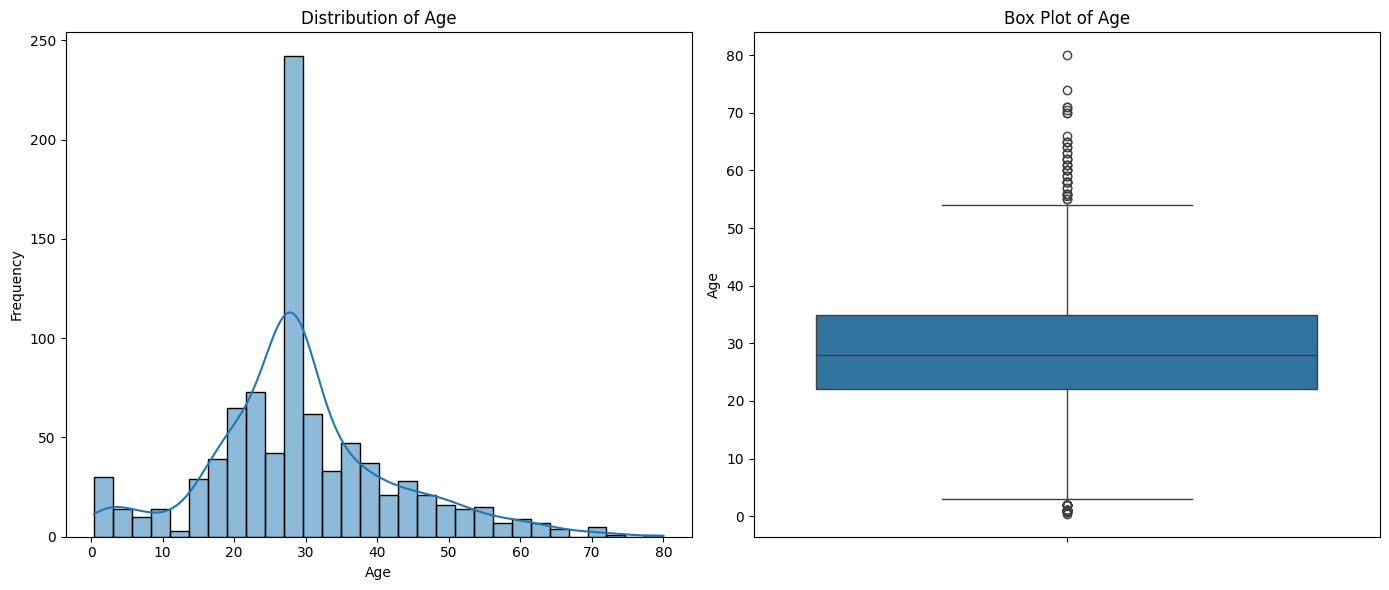

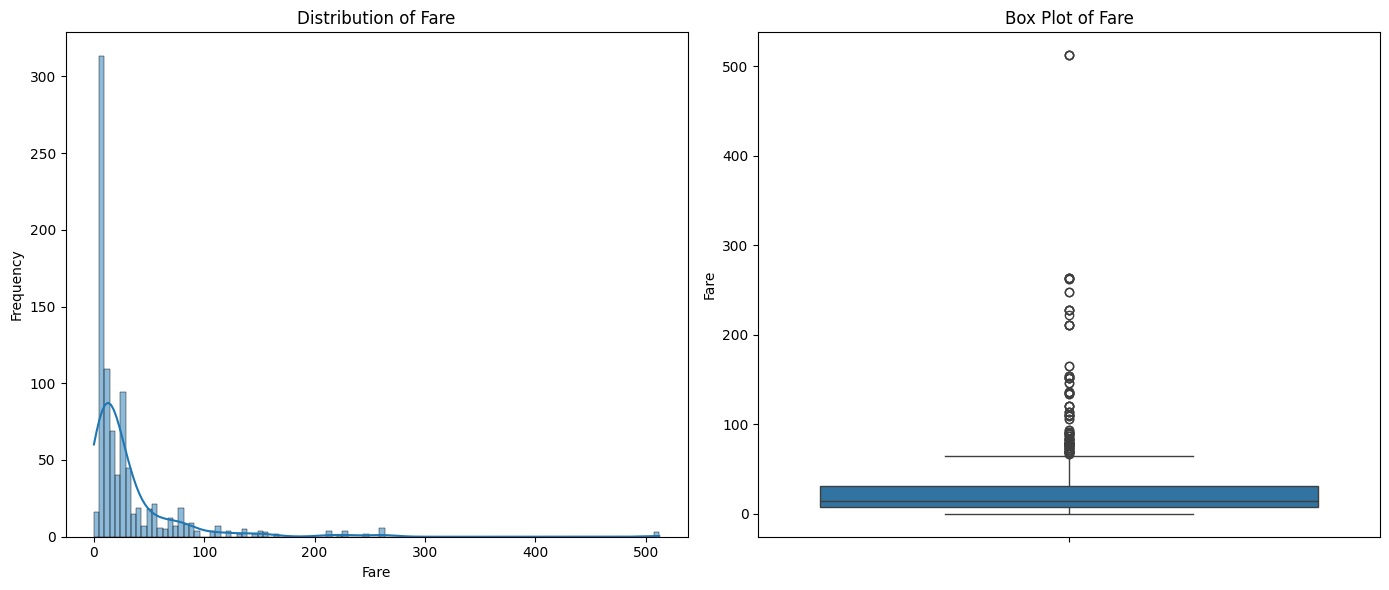


--- Outlier Analysis for Age ---
Q1 (Age): 22.00
Q3 (Age): 35.00
IQR (Age): 13.00
Lower Bound (Age): 2.50
Upper Bound (Age): 54.50
Number of outliers for Age: 65

--- Outlier Analysis for Fare ---
Q1 (Fare): 7.90
Q3 (Fare): 31.00
IQR (Fare): 23.10
Lower Bound (Fare): -26.76
Upper Bound (Fare): 65.66
Number of outliers for Fare: 114

--- Fare Statistics and Skewness ---
Mean of Fare: 32.10
Median of Fare: 14.45
Mode of Fare: 8.05
Skewness of Fare distribution: Positively skewed (right-skewed). This indicates a tail on the right side of the distribution, with a larger number of lower fare values and fewer, but higher, fare values pulling the mean up.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure plots are displayed inline
%matplotlib inline

print("--- Univariate Analysis for 'age' and 'fare' ---")

# 1. Plotting 'age'
plt.figure(figsize=(14, 6))

# Histogram for age
plt.subplot(1, 2, 1)
sns.histplot(df_titanic['age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Box plot for age
plt.subplot(1, 2, 2)
sns.boxplot(y=df_titanic['age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

# 2. Plotting 'fare'
plt.figure(figsize=(14, 6))

# Histogram for fare
plt.subplot(1, 2, 1)
sns.histplot(df_titanic['fare'], kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')

# Box plot for fare
plt.subplot(1, 2, 2)
sns.boxplot(y=df_titanic['fare'])
plt.title('Box Plot of Fare')
plt.ylabel('Fare')

plt.tight_layout()
plt.show()

# 3. Outlier Detection using IQR for 'age'
Q1_age = df_titanic['age'].quantile(0.25)
Q3_age = df_titanic['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

outliers_age = df_titanic[(df_titanic['age'] < lower_bound_age) | (df_titanic['age'] > upper_bound_age)]
num_outliers_age = len(outliers_age)

print(f"\n--- Outlier Analysis for Age ---")
print(f"Q1 (Age): {Q1_age:.2f}")
print(f"Q3 (Age): {Q3_age:.2f}")
print(f"IQR (Age): {IQR_age:.2f}")
print(f"Lower Bound (Age): {lower_bound_age:.2f}")
print(f"Upper Bound (Age): {upper_bound_age:.2f}")
print(f"Number of outliers for Age: {num_outliers_age}")

# 4. Outlier Detection using IQR for 'fare'
Q1_fare = df_titanic['fare'].quantile(0.25)
Q3_fare = df_titanic['fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_bound_fare = Q1_fare - 1.5 * IQR_fare
upper_bound_fare = Q3_fare + 1.5 * IQR_fare

outliers_fare = df_titanic[(df_titanic['fare'] < lower_bound_fare) | (df_titanic['fare'] > upper_bound_fare)]
num_outliers_fare = len(outliers_fare)

print(f"\n--- Outlier Analysis for Fare ---")
print(f"Q1 (Fare): {Q1_fare:.2f}")
print(f"Q3 (Fare): {Q3_fare:.2f}")
print(f"IQR (Fare): {IQR_fare:.2f}")
print(f"Lower Bound (Fare): {lower_bound_fare:.2f}")
print(f"Upper Bound (Fare): {upper_bound_fare:.2f}")
print(f"Number of outliers for Fare: {num_outliers_fare}")

# 5. Compute mean, median, and mode for 'fare'
mean_fare = df_titanic['fare'].mean()
median_fare = df_titanic['fare'].median()
mode_fare = df_titanic['fare'].mode()[0] # mode() can return multiple values, so take the first

print(f"\n--- Fare Statistics and Skewness ---")
print(f"Mean of Fare: {mean_fare:.2f}")
print(f"Median of Fare: {median_fare:.2f}")
print(f"Mode of Fare: {mode_fare:.2f}")

# 6. Determine skewness based on mean, median, mode
if mean_fare > median_fare:
    skewness_description = "Positively skewed (right-skewed). This indicates a tail on the right side of the distribution, with a larger number of lower fare values and fewer, but higher, fare values pulling the mean up."
elif mean_fare < median_fare:
    skewness_description = "Negatively skewed (left-skewed). This indicates a tail on the left side of the distribution, with a larger number of higher fare values and fewer, but lower, fare values pulling the mean down."
else:
    skewness_description = "Symmetrical or close to symmetrical. Mean, median, and mode are approximately equal."

print(f"Skewness of Fare distribution: {skewness_description}")


--- Bivariate Analysis: Age, Fare, and Survived ---


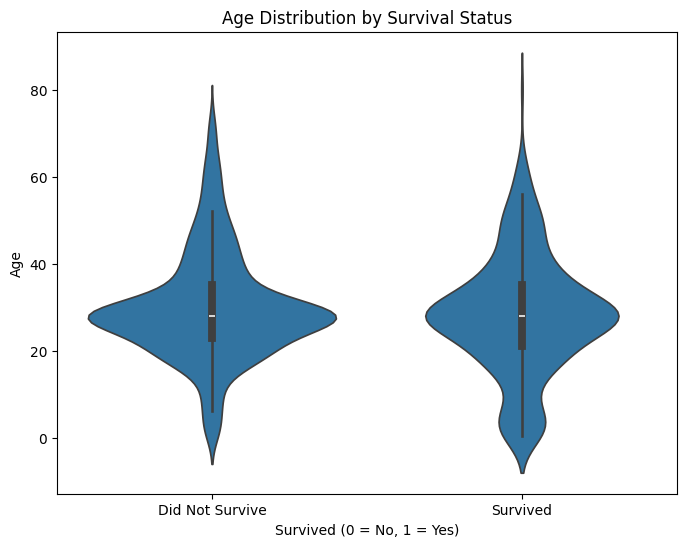

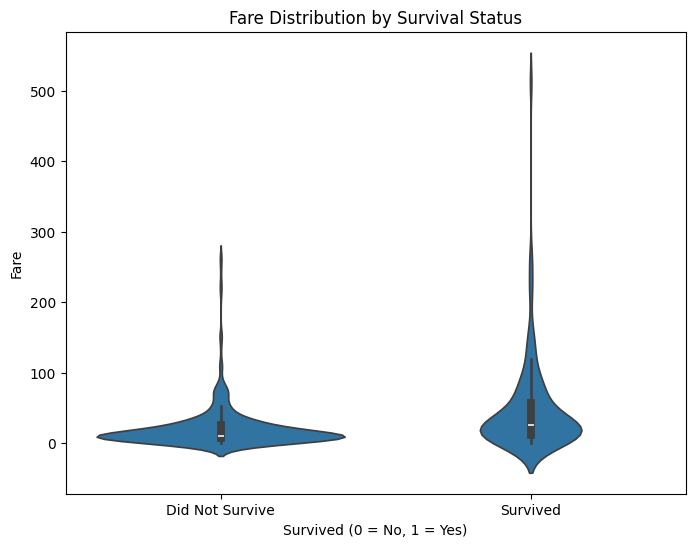

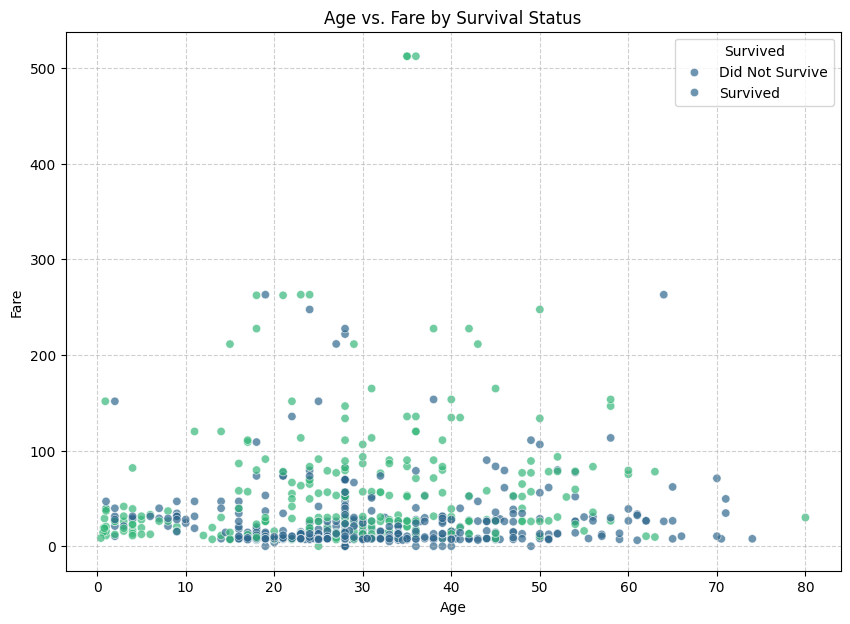

Bivariate analysis plots generated.


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Bivariate Analysis: Age, Fare, and Survived ---")

# 1. Violin plot of 'Age' vs. 'Survived'
plt.figure(figsize=(8, 6))
sns.violinplot(x='survived', y='age', data=df_titanic)
plt.title('Age Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.show()

# 2. Violin plot of 'Fare' vs. 'Survived'
plt.figure(figsize=(8, 6))
sns.violinplot(x='survived', y='fare', data=df_titanic)
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.show()

# 3. Scatter plot of 'Age' vs. 'Fare', colored by 'Survived'
plt.figure(figsize=(10, 7))
sns.scatterplot(x='age', y='fare', hue='survived', data=df_titanic, palette='viridis', alpha=0.7)
plt.title('Age vs. Fare by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(title='Survived', labels=['Did Not Survive', 'Survived'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Bivariate analysis plots generated.")

--- Multivariate Analysis ---



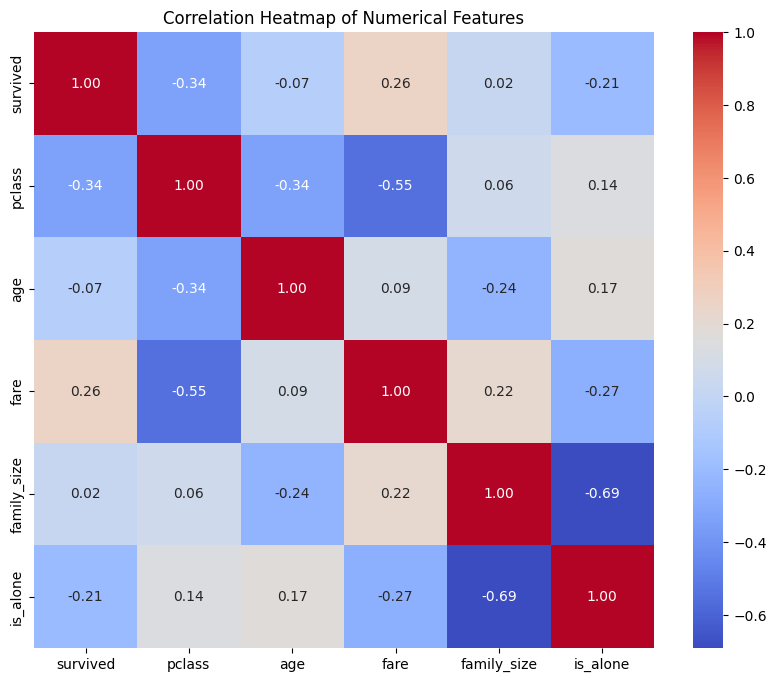

Generating PairPlot for key numerical features...


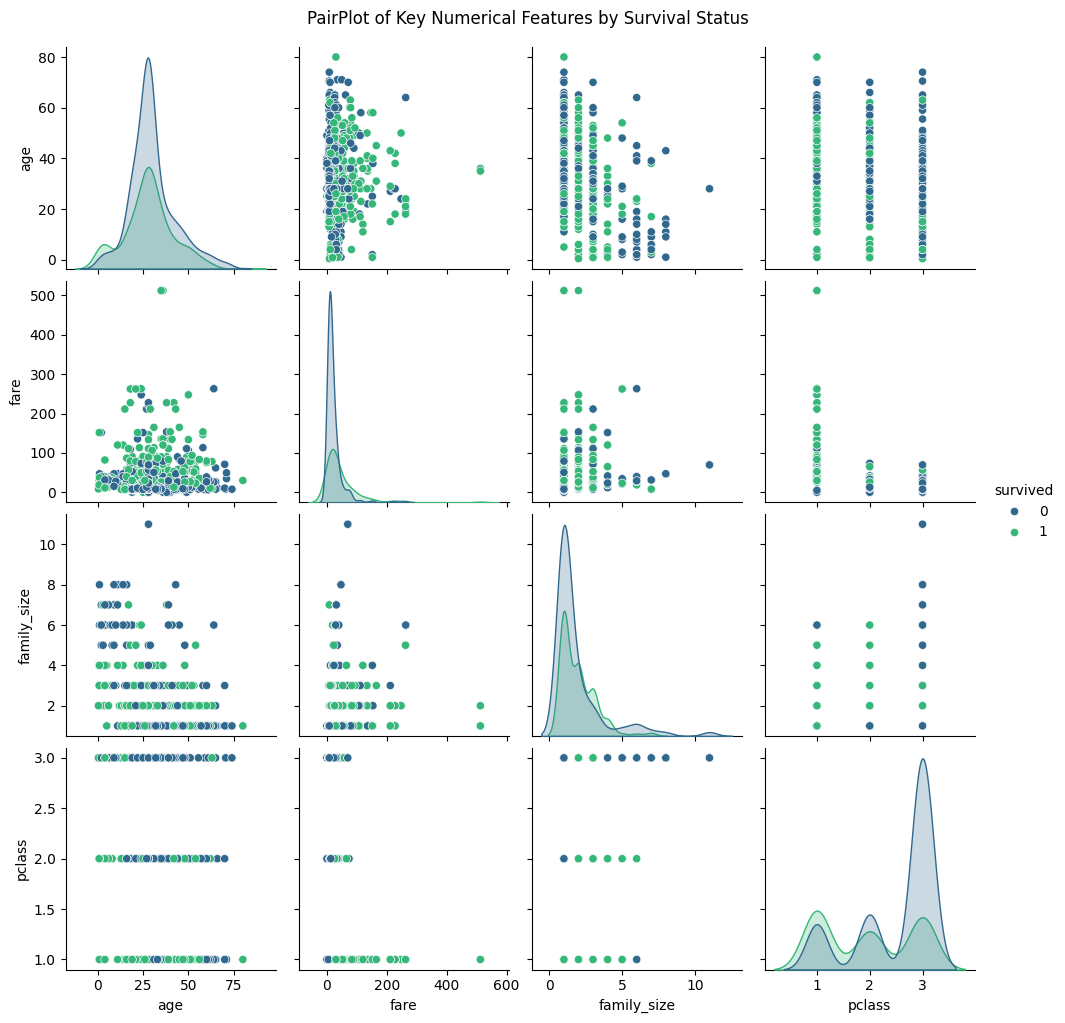

Multivariate analysis plots generated.


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Multivariate Analysis ---\n")

# 1. Create a heatmap of correlations between numerical features
# Select only numerical columns for correlation calculation
# Filter out boolean columns from correlation if they are treated as objects and not int/float
numerical_df = df_titanic.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 2. Use a PairPlot to explore relationships between key numerical features and 'survived' status
# For PairPlot, selecting a subset of features to avoid overly crowded plot
# 'survived' is the target variable

# Include 'survived', 'age', 'fare', 'family_size', and 'pclass' for the pair plot
key_features = ['survived', 'age', 'fare', 'family_size', 'pclass']

# Ensure these columns are in the dataframe, if not, adjust
existing_key_features = [col for col in key_features if col in df_titanic.columns]

if 'survived' not in existing_key_features:
    print("Warning: 'survived' column not found for pair plot.")

print("Generating PairPlot for key numerical features...")
sns.pairplot(df_titanic[existing_key_features], hue='survived', palette='viridis', diag_kind='kde')
plt.suptitle('PairPlot of Key Numerical Features by Survival Status', y=1.02) # Adjust suptitle position
plt.show()

print("Multivariate analysis plots generated.")

--- Survival Rates Analysis ---

Survival Rate by Sex:
      sex  survived
0  Female  0.740385
1    Male  0.188908

Survival Rate by Pclass:
   pclass  survived
0       1  0.626168
1       2  0.472826
2       3  0.242363

Survival Rate by Sex and Pclass:
pclass         1         2         3
sex                                 
Female  0.967391  0.921053  0.500000
Male    0.368852  0.157407  0.135447

--- Correlation Analysis ---

Correlation Matrix of Selected Numerical Features:
             survived    pclass       age      fare  family_size  is_alone
survived     1.000000 -0.335549 -0.069822  0.255290     0.018277 -0.206207
pclass      -0.335549  1.000000 -0.336512 -0.548193     0.064221  0.138553
age         -0.069822 -0.336512  1.000000  0.093707    -0.244631  0.169518
fare         0.255290 -0.548193  0.093707  1.000000     0.218658 -0.274079
family_size  0.018277  0.064221 -0.244631  0.218658     1.000000 -0.690654
is_alone    -0.206207  0.138553  0.169518 -0.274079    -0.690654 

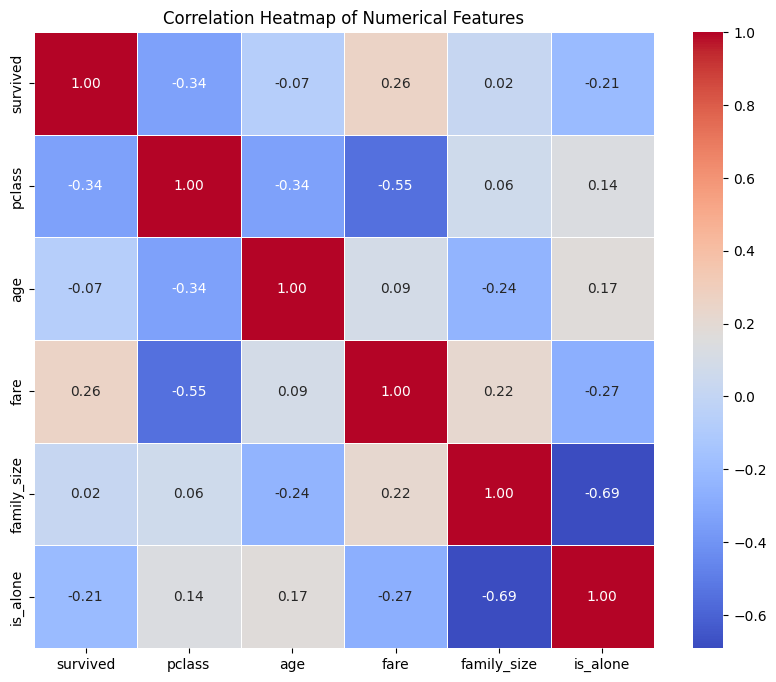


--- Strongest Absolute Correlations (excluding self-correlations) ---

1. family_size and is_alone: -0.69 (Absolute: 0.69)
   Interpretation: There is a strong negative correlation. As family_size increases, is_alone tends to decrease significantly.

2. pclass and fare: -0.55 (Absolute: 0.55)
   Interpretation: There is a strong negative correlation. As pclass increases, fare tends to decrease significantly.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Survival Rates Analysis ---")

# 1. Survival rate by sex
survival_by_sex = df_titanic.groupby('sex_male')['survived'].mean().reset_index()
survival_by_sex['sex'] = survival_by_sex['sex_male'].map({True: 'Male', False: 'Female'})
print("\nSurvival Rate by Sex:")
print(survival_by_sex[['sex', 'survived']])

# 2. Survival rate by pclass
survival_by_pclass = df_titanic.groupby('pclass')['survived'].mean().reset_index()
print("\nSurvival Rate by Pclass:")
print(survival_by_pclass)

# 3. Survival rates by sex and pclass combined
# We need to map the one-hot encoded 'sex_male' back to 'sex' for clearer grouping
# And also map pclass to descriptive categories
df_titanic_temp = df_titanic.copy()
df_titanic_temp['sex'] = df_titanic_temp['sex_male'].map({True: 'Male', False: 'Female'})
survival_by_sex_pclass = df_titanic_temp.groupby(['sex', 'pclass'])['survived'].mean().unstack()
print("\nSurvival Rate by Sex and Pclass:")
print(survival_by_sex_pclass)

print("\n--- Correlation Analysis ---")

# 4. Identify numerical features for correlation matrix
# Using the specified columns: 'survived', 'pclass', 'age', 'fare', 'family_size', 'is_alone'
correlation_features = ['survived', 'pclass', 'age', 'fare', 'family_size', 'is_alone']

# Ensure all specified features exist in the DataFrame
# 'family_size' and 'is_alone' were created and are int/float
# 'pclass', 'age', 'fare' are already int/float
# 'survived' is int

existing_correlation_features = [col for col in correlation_features if col in df_titanic.columns]

if len(existing_correlation_features) != len(correlation_features):
    print(f"Warning: Some specified correlation features were not found. Using: {existing_correlation_features}")

# Select the relevant columns for the correlation matrix
df_corr = df_titanic[existing_correlation_features]

# 5. Compute the correlation matrix
correlation_matrix = df_corr.corr()
print("\nCorrelation Matrix of Selected Numerical Features:")
print(correlation_matrix)

# 6. Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 7. Identify and report the two strongest absolute correlations (excluding self-correlations)
# Get the absolute values of the correlations
abs_corr_matrix = correlation_matrix.abs()

# Fill diagonal with NaN to exclude self-correlations
np.fill_diagonal(abs_corr_matrix.values, np.nan)

# Unstack the matrix to easily find the top correlations
stacked_corr = abs_corr_matrix.unstack()

# Sort in descending order and get the top 2 unique pairs
sorted_corr = stacked_corr.sort_values(ascending=False)

# Get unique pairs, ensuring we don't repeat (e.g., A-B and B-A)
top_correlations = []
seen_pairs = set()

for (idx1, idx2), value in sorted_corr.items():
    if (idx1, idx2) not in seen_pairs and (idx2, idx1) not in seen_pairs and not pd.isna(value):
        top_correlations.append(((idx1, idx2), value))
        seen_pairs.add((idx1, idx2))
        seen_pairs.add((idx2, idx1))
    if len(top_correlations) == 2:
        break

print("\n--- Strongest Absolute Correlations (excluding self-correlations) ---")
if top_correlations:
    for i, ((feature1, feature2), correlation_value) in enumerate(top_correlations):
        original_corr_value = correlation_matrix.loc[feature1, feature2] # Get original signed value
        print(f"\n{i+1}. {feature1} and {feature2}: {original_corr_value:.2f} (Absolute: {correlation_value:.2f})")
        if original_corr_value > 0.5: # Example threshold for strong positive
            print(f"   Interpretation: There is a strong positive correlation. As {feature1} increases, {feature2} tends to increase significantly.")
        elif original_corr_value < -0.5: # Example threshold for strong negative
            print(f"   Interpretation: There is a strong negative correlation. As {feature1} increases, {feature2} tends to decrease significantly.")
        else:
            print(f"   Interpretation: This is a notable correlation. {'A positive relationship' if original_corr_value > 0 else 'A negative relationship'} exists where a change in {feature1} is associated with a {'similar' if original_corr_value > 0 else 'opposite'} change in {feature2}.")
else:
    print("No strong correlations found.")


--- Multivariate Data Story Plots ---


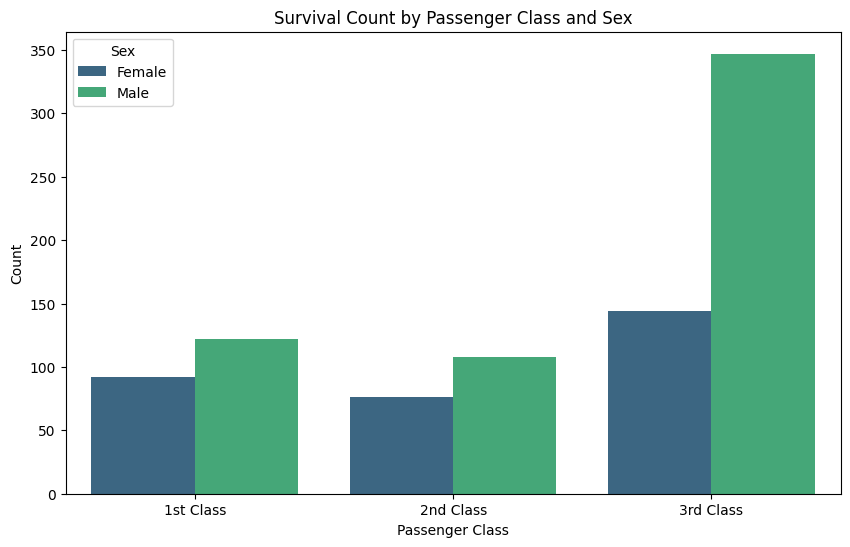

Interpretation 1: This plot clearly shows that female passengers, regardless of class, had a higher survival count than male passengers. Within each class, there are significantly more male passengers who did not survive compared to females. This indicates that gender was a major factor influencing survival on the Titanic.


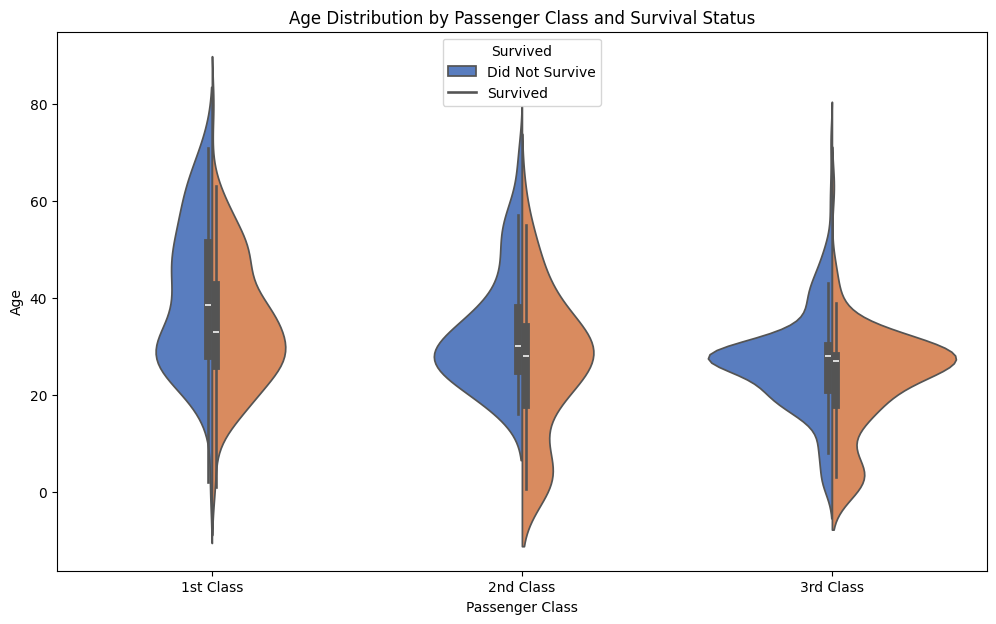

Interpretation 2: In 1st and 2nd class, younger passengers (especially children) show a higher propensity to survive. In 3rd class, the age distribution for non-survivors is broader, suggesting that age might have played a less protective role for third-class passengers in general, although very young children in 3rd class still show a survival advantage.


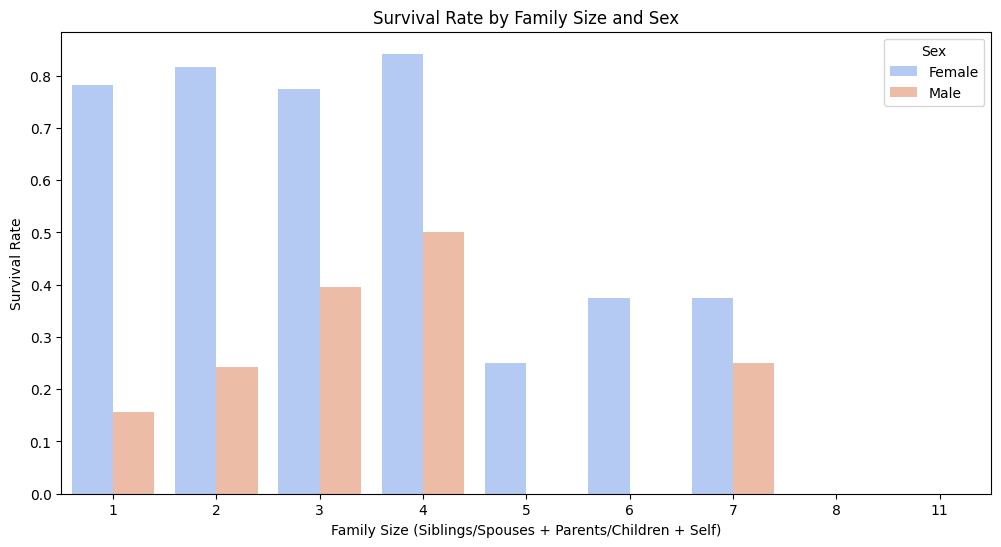

Interpretation 3: This plot reveals that females consistently had higher survival rates across all family sizes. Passengers with small to medium family sizes (1 to 4 members) generally had higher survival rates, especially for females. Conversely, very large family sizes (5 or more) resulted in significantly lower survival rates for both genders, likely due to difficulties in evacuating together.


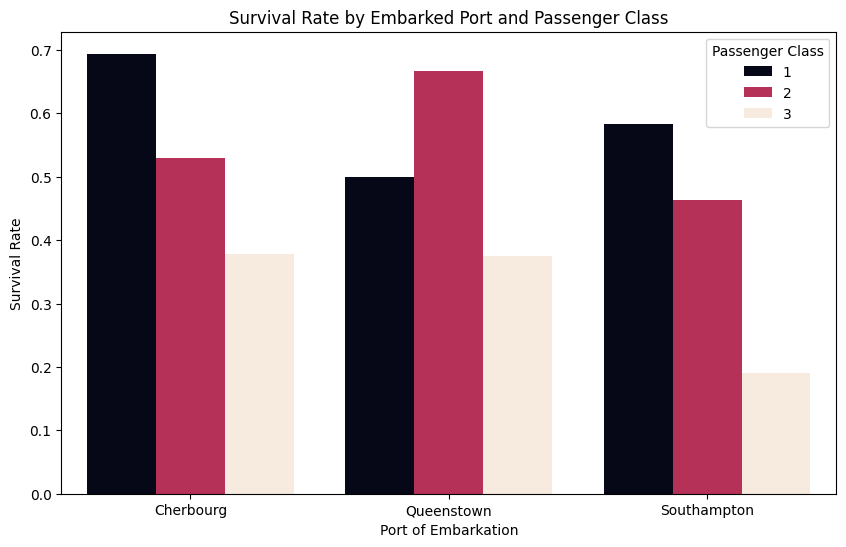

Interpretation 4: Passengers from Cherbourg (C) generally had higher survival rates, particularly those in 1st and 2nd class, while those from Southampton (S) had the lowest, especially for 3rd class. Queenstown (Q) passengers had mixed survival, with 2nd class showing a surprisingly high rate despite a smaller sample size.
Multivariate data story plots generated.

--- Standardization of 'age' and 'fare' ---


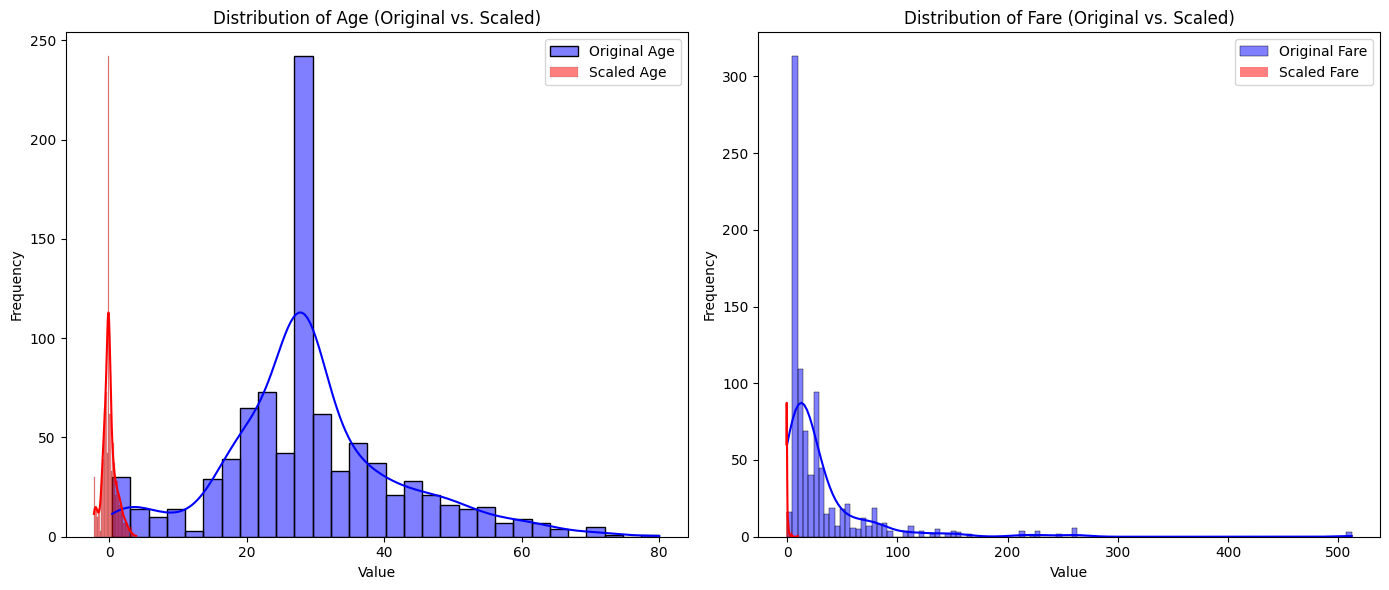

Z-score standardization applied to 'age' and 'fare'. Distributions before and after scaling are shown. The shapes of the distributions are preserved, but they are now centered around 0 with a standard deviation of 1, which is characteristic of z-score standardization.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np

# Ensure plots are displayed inline
%matplotlib inline

print("--- Multivariate Data Story Plots ---")

# Plot 1: Countplot of Survived by Pclass and Sex
plt.figure(figsize=(10, 6))
sns.countplot(x='pclass', hue='sex_male', data=df_titanic, palette='viridis')
plt.title('Survival Count by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'])
plt.legend(title='Sex', labels=['Female', 'Male'])
plt.show()
print("Interpretation 1: This plot clearly shows that female passengers, regardless of class, had a higher survival count than male passengers. Within each class, there are significantly more male passengers who did not survive compared to females. This indicates that gender was a major factor influencing survival on the Titanic.")

# Plot 2: Violin Plot of Age vs. Survived by Pclass
plt.figure(figsize=(12, 7))
sns.violinplot(x='pclass', y='age', hue='survived', data=df_titanic, palette='muted', split=True)
plt.title('Age Distribution by Passenger Class and Survival Status')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.xticks([0, 1, 2], ['1st Class', '2nd Class', '3rd Class'])
plt.legend(title='Survived', labels=['Did Not Survive', 'Survived'])
plt.show()
print("Interpretation 2: In 1st and 2nd class, younger passengers (especially children) show a higher propensity to survive. In 3rd class, the age distribution for non-survivors is broader, suggesting that age might have played a less protective role for third-class passengers in general, although very young children in 3rd class still show a survival advantage.")

# Plot 3: Bar Plot of Survival Rate by Family Size and Sex
df_titanic['sex_label'] = df_titanic['sex_male'].map({True: 'Male', False: 'Female'})
survival_rate_family_sex = df_titanic.groupby(['family_size', 'sex_label'])['survived'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='family_size', y='survived', hue='sex_label', data=survival_rate_family_sex, palette='coolwarm')
plt.title('Survival Rate by Family Size and Sex')
plt.xlabel('Family Size (Siblings/Spouses + Parents/Children + Self)')
plt.ylabel('Survival Rate')
plt.legend(title='Sex')
plt.show()
print("Interpretation 3: This plot reveals that females consistently had higher survival rates across all family sizes. Passengers with small to medium family sizes (1 to 4 members) generally had higher survival rates, especially for females. Conversely, very large family sizes (5 or more) resulted in significantly lower survival rates for both genders, likely due to difficulties in evacuating together.")

# Plot 4: Bar Plot of Survival Rate by Embarked Port and Passenger Class
# Convert one-hot encoded 'embarked' back to a single categorical column for plotting clarity
def get_embarked_port(row):
    if row['embarked_Q']:
        return 'Queenstown'
    elif row['embarked_S']:
        return 'Southampton'
    else:
        return 'Cherbourg' # C is the base category if Q and S are False

df_titanic['embarked_port'] = df_titanic.apply(get_embarked_port, axis=1)

survival_rate_embarked_pclass = df_titanic.groupby(['embarked_port', 'pclass'])['survived'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='embarked_port', y='survived', hue='pclass', data=survival_rate_embarked_pclass, palette='rocket')
plt.title('Survival Rate by Embarked Port and Passenger Class')
plt.xlabel('Port of Embarkation')
plt.ylabel('Survival Rate')
plt.legend(title='Passenger Class')
plt.show()
print("Interpretation 4: Passengers from Cherbourg (C) generally had higher survival rates, particularly those in 1st and 2nd class, while those from Southampton (S) had the lowest, especially for 3rd class. Queenstown (Q) passengers had mixed survival, with 2nd class showing a surprisingly high rate despite a smaller sample size.")

print("Multivariate data story plots generated.")

# --- Standardization Check ---
print("\n--- Standardization of 'age' and 'fare' ---")

# Create a temporary DataFrame for standardization to avoid modifying the original df_titanic for this exploratory check
df_titanic_temp_scaled = df_titanic.copy()

# Initialize StandardScaler
scaler = StandardScaler()

# Apply standardization to 'age' and 'fare'
df_titanic_temp_scaled['age_scaled'] = scaler.fit_transform(df_titanic_temp_scaled[['age']])
df_titanic_temp_scaled['fare_scaled'] = scaler.fit_transform(df_titanic_temp_scaled[['fare']])

# Visualize distributions before and after scaling
plt.figure(figsize=(14, 6))

# Age: Original vs. Scaled
plt.subplot(1, 2, 1)
sns.histplot(df_titanic_temp_scaled['age'], kde=True, color='blue', label='Original Age')
sns.histplot(df_titanic_temp_scaled['age_scaled'], kde=True, color='red', label='Scaled Age')
plt.title('Distribution of Age (Original vs. Scaled)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

# Fare: Original vs. Scaled
plt.subplot(1, 2, 2)
sns.histplot(df_titanic_temp_scaled['fare'], kde=True, color='blue', label='Original Fare')
sns.histplot(df_titanic_temp_scaled['fare_scaled'], kde=True, color='red', label='Scaled Fare')
plt.title('Distribution of Fare (Original vs. Scaled)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

print("Z-score standardization applied to 'age' and 'fare'. Distributions before and after scaling are shown. The shapes of the distributions are preserved, but they are now centered around 0 with a standard deviation of 1, which is characteristic of z-score standardization.")
